## <font color = #0288d1>简单分类问题</font>
### 本节来讨论一个简单的分类问题。由于将使用sklearn包来产生模拟数据，所以学习本节内容，请先安装sklearn包:
> ### pip install scikit-learn

In [1]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

+ ### 使用make_moons函数来产生一些模拟数据。这些数据可以看作是2维平面上的一些点，因此数据具有2个特征量x1和x2。
+ ### 这些点分为2种颜色，蓝色和红色。蓝色的点具有标签值1，称为正例。红色的点具有标签值0，是反例。
+ ### 模拟产生100个数据点，加入了高斯噪声值，同时指定了随机数种子为0使得数据可以复现。
+ ### 产生数据之后使用sklearn的train_test_split函数将数据随机的分为训练集和测试集。train_test_split函数的第3个参数指出了测试集的大小，第四个参数给定了随机数种子。此处将数据分为了80个训练数据和20个验证数据

In [2]:
X, y = make_moons(n_samples=100, noise=0.3, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.2, random_state=13)

+ ### 使用sklearn的标准化方法对数据进行标准化。
+ ### 标准化的方法是首先实例化一个标准化对象，然后通过训练集的数据计算得到标准化参数，随后根据这个参数对所有数据进行标准化。
+ ### 特别注意，<font color="purple">**仅仅应该通过训练集来计算标准化参数而不是所有数据**</font>。因为验证集的数据是在训练完模型之后用来验证的，在训练的时候其信息对模型应该是未知的

In [3]:
sc = StandardScaler()
sc.fit(X_train)

X_train = sc.transform(X_train)
X_val = sc.transform(X_val)

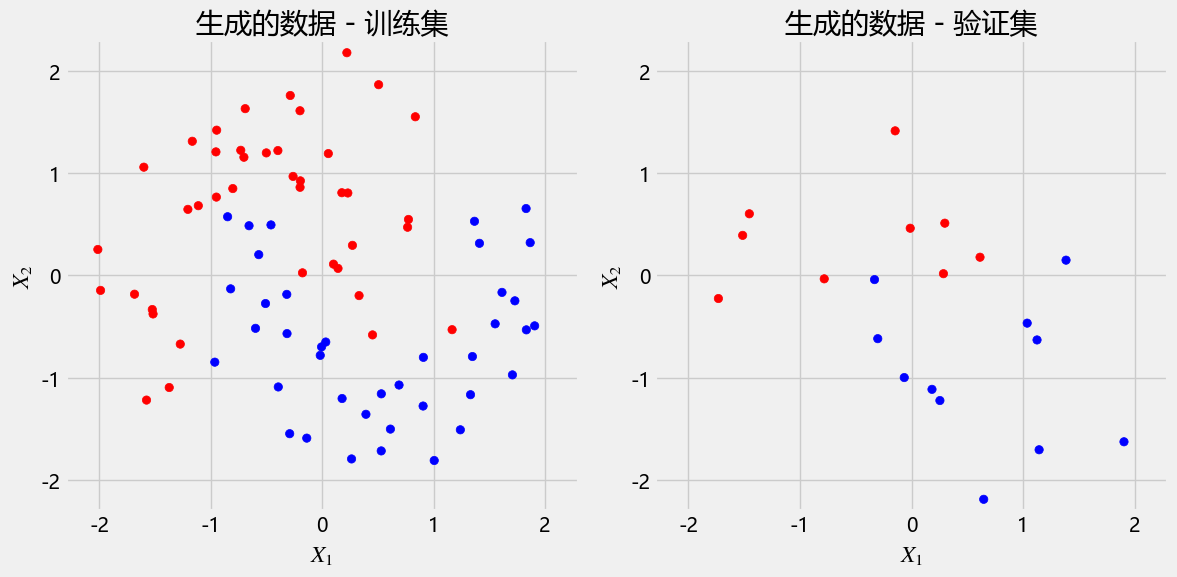

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.style.use('fivethirtyeight')

def figure1(X_train, y_train, X_val, y_val, cm_bright=None):
    if cm_bright is None:
        cm_bright = ListedColormap(['#FF0000', '#0000FF'])

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright)
    ax[0].set_xlabel(r'$X_1$')
    ax[0].set_ylabel(r'$X_2$')
    ax[0].set_xlim([-2.3, 2.3])
    ax[0].set_ylim([-2.3, 2.3])
    ax[0].set_title('生成的数据 - 训练集')

    ax[1].scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap=cm_bright)
    ax[1].set_xlabel(r'$X_1$')
    ax[1].set_ylabel(r'$X_2$')
    ax[1].set_xlim([-2.3, 2.3])
    ax[1].set_ylim([-2.3, 2.3])
    ax[1].set_title('生成的数据 - 验证集')
    fig.tight_layout()
    
    return fig

fig = figure1(X_train, y_train, X_val, y_val)

In [5]:
import numpy as np
import torch
import torch.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

+ ### Dataset和DataLoader是两个用于数据处理和加载的重要组件，Dataset是一个抽象类，用于表示数据集。如果需要创建自己dataset，需要从Dataset类继承，本书不使用自定义的dataset，也就不展开讨论了。
+ ### DataLoader是一个用于批量加载数据的工具，它可以将Dataset中的数据进行批量处理、打乱顺序、并行加载等操作。DataLoader可以显著提高数据加载的效率，特别是在处理大规模数据集时。创建DataLoader类时用到的主要参数有：
- ### dataset：要加载的数据集，必须是 `torch.utils.data.Dataset`  类的实例。
- ### batch_size：每个批次加载的样本数量。
- ### shuffle：是否在每个 epoch 开始时打乱数据集的顺序。

In [6]:
torch.manual_seed(23)

# 从numpy数组转换为张量，并转置了y
x_train_tensor = torch.as_tensor(X_train).float()
y_train_tensor = torch.as_tensor(y_train.reshape(-1, 1)).float()

x_val_tensor = torch.as_tensor(X_val).float()
y_val_tensor = torch.as_tensor(y_val.reshape(-1, 1)).float()

# 创建数据集
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

# 创建DataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=16)

### 本问题是一个具有两个特征的线性回归模型：

### $$ y = w_{1}x_{1} + w_{2}x_{2} + b + \varepsilon $$

### 根据2个特征值x1和x2计算出y值，当概率大于等于0.5时，认为分类的值为1；当概率值小于0.5时确定为0。同时为了这个概率值具有对称性，对其取了对数。

### $$ \ln\left(\frac{p}{1 - p}\right) = z = w_{1}x_{1} + w_{2}x_{2} + b $$
### $$ \frac{p}{1 - p} = \ e^{z} = e^{w_{1}x_{1} + w_{2}x_{2} + b} $$
### $$ p = \frac{1}{1 + e^{- z}} = \sigma(z) = \sigma(w_{1}x_{1} + w_{2}x_{2} + b) $$

In [7]:
# 定义模型
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 线性层，输入维度2，输出维度1
        self.linear = nn.Linear(2, 1)
        # Sigmoid输出层
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.linear(x)
        return self.sigmoid(y)


In [8]:
def mini_batch_train(data_loader,model,optimizer,loss_fn):
    mini_batch_losses = []
    for x_batch, y_batch in data_loader:
        # 置为训练状态
        model.train()
        # Step 1 - 前向计算预测值
        yhat = model(x_batch)
        # Step 2 - 计算损失
        mini_batch_loss = loss_fn(yhat, y_batch)
        # Step 3 - 计算梯度
        mini_batch_loss.backward()
        # Step 4 - 参数更新
        optimizer.step()
        optimizer.zero_grad()

        mini_batch_losses.append(mini_batch_loss.item())
                  
    loss = np.mean(mini_batch_losses)
    return loss

In [9]:
def mini_batch_val(data_loader,model,loss_fn):
    mini_batch_losses = []
    for x_batch, y_batch in data_loader:
        # 置为验证状态
        model.eval()
        # Step 1 - 前向计算预测值
        yhat = model(x_batch)
        # Step 2 - 计算损失
        mini_batch_loss = loss_fn(yhat, y_batch)
        mini_batch_losses.append(mini_batch_loss.item())
                  
    loss = np.mean(mini_batch_losses)
    return loss

### $$ BCE(y) = - \frac{1}{N_{pos} + N_{neg}}\left\lbrack \sum_{i = 1}^{pos}{ln(P\left( y_{i} = 1 \right))} + \sum_{i = neg}^{neg}{ln(1 - p\left( y_{i} = 1 \right))} \right\rbrack$$

### 由于y的取值要么为1，要么为0，为了方便计算而不用先统计有几个正例或反例，上述公式也可以写为：

### $$BCE(y) = - \frac{1}{N}\sum_{i = 1}^{N}{{\lbrack y}_{i}ln(}P(y_{i} = 1)) + (1 - y_{i})ln(1 - P(y_{i} = 1))\rbrack$$

### 最后，和期望的一样，PyTorch提供了BCELoss类：

### `loss_fn = nn.BCELoss(reduction='mean')`

In [10]:
n_epochs = 100

# 指定随机数种子，可以再现数据
np.random.seed(23)
torch.manual_seed(23)

# 循环轮数计数
total_epochs = 0

losses = []  # 每轮训练的损失
val_losses = [] #  每轮验证数据的损失
lr = 0.1  # 学习率

# 定义模型
model = ClassificationModel()

# 定义优化器
optimizer = optim.SGD(model.parameters(), lr=lr)

# 定义损失函数
loss_fn = nn.BCELoss(reduction='mean')

for epoch in range(n_epochs):
    total_epochs += 1

    # 进入mini-batch的内循环
    loss = mini_batch_train(train_loader,model,optimizer,loss_fn)
    losses.append(loss)

    # 验证数据集（验证不需要计算梯度）
    with torch.no_grad():
        # 验证集的 mini_batch
        val_loss = mini_batch_val(val_loader,model,loss_fn)
        val_losses.append(val_loss)

print(model.state_dict())

OrderedDict({'linear.weight': tensor([[ 1.1841, -1.8763]]), 'linear.bias': tensor([-0.0604])})


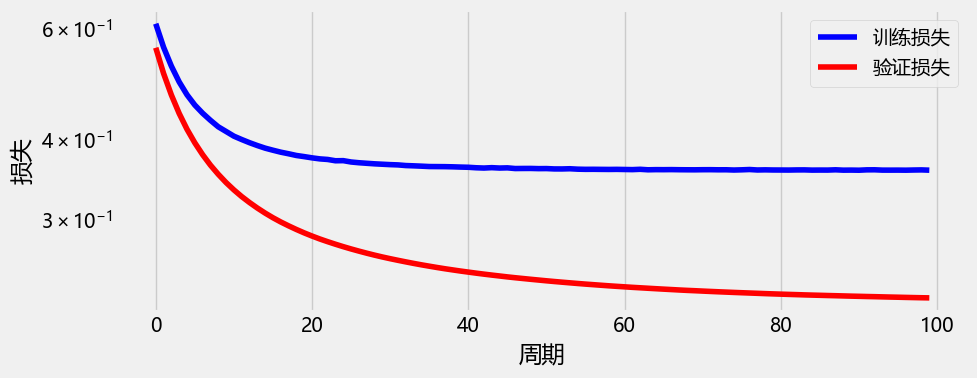

In [ ]:
def plot_losses():
        
    fig = plt.figure(figsize=(10, 4))
    plt.plot(losses, label='训练损失', c='b')
    plt.plot(val_losses, label='验证损失', c='r')
    plt.yscale('log')
    plt.xlabel('周期')
    plt.ylabel('损失')
    plt.legend()
    plt.tight_layout()
   
    return fig

fig=plot_losses()